# Mark - The Top 10 Verbs

What should be the top 10, most frequent verbs to know in the Gospel of Mark?

In [14]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# Load the transformer model
nlp = spacy.load("grc_odycy_joint_trf")

# Read the Mark Greek text
with open("data/NT/Greek/Mark-greek.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Remove verse numbers to fix tokenization
text = re.sub(r'\d+', ' ', text)

doc = nlp(text)

# Extract tokens with POS and Morphological features
data = [
    (token.text, token.lemma_, token.pos_, token.morph)
    for token in doc
    if token.is_alpha # we exclude all non-alphabetical-made token (punctuation, etc.)
]

df = pd.DataFrame(data, columns=["Token", "Lemma", "POS", "Morph"])

# 🔹 Count Verbs
verbs = df[df["POS"] == "VERB"]
print("Number of Greek verbs in Mark:", len(verbs))

Number of Greek verbs in Mark: 2451


## Count the top 10 most frequent verbs:

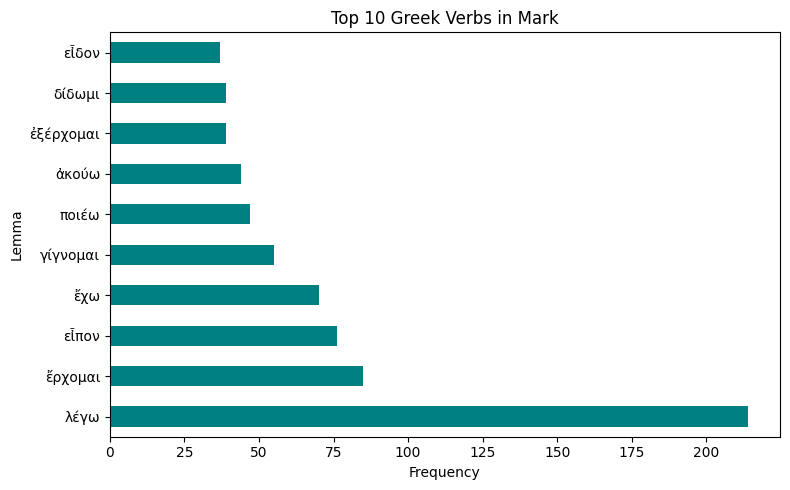

In [15]:
# 🔹 Plot verb lemmas frequency
verb_counts = verbs["Lemma"].value_counts().head(10)
verb_counts.plot(kind="barh", title="Top 10 Greek Verbs in Mark", figsize=(8,5), color="teal")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()